In [ ]:
import pandas as pd
import numpy as np

# ডাটা ফাইলটি লোড করুন
df = pd.read_csv('all_matches.csv')

# ডাটার প্রথম ৫টি রো (rows) দেখুন
print(df.head())

         date home_team away_team  home_score  away_score tournament  \
0  1872-11-30  Scotland   England           0           0   Friendly   
1  1873-03-08   England  Scotland           4           2   Friendly   
2  1874-03-07  Scotland   England           2           1   Friendly   
3  1875-03-06   England  Scotland           2           2   Friendly   
4  1876-03-04  Scotland   England           3           0   Friendly   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  


In [ ]:
# 'date' কলামটিকে ডেট-টাইম ফরম্যাটে কনভার্ট করুন
df['date'] = pd.to_datetime(df['date'])

# শুধুমাত্র ২০১০ সালের পরের ম্যাচগুলো লুফে নিন
df = df[df['date'] >= '2010-01-01'].reset_index(drop=True)

In [ ]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 1  # Home Team জিতেছে
    elif row['home_score'] < row['away_score']:
        return 2  # Away Team জিতেছে
    else:
        return 0  # Draw হয়েছে

df['match_result'] = df.apply(get_result, axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# সব দেশের নামকে একটি ইউনিক সংখ্যায় রূপান্তর করুন
# (যেমন: Argentina = 0, Bangladesh = 5, Brazil = 12 ইত্যাদি)
all_teams = pd.concat([df['home_team'], df['away_team']]).unique()
le.fit(all_teams)

df['home_team_code'] = le.transform(df['home_team'])
df['away_team_code'] = le.transform(df['away_team'])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ইনপুট ফিচার এবং আউটপুট টার্গেট সিলেক্ট করুন
X = df[['home_team_code', 'away_team_code', 'neutral']]
y = df['match_result']

# ডাটাকে Training এবং Testing সেটে ভাগ করুন (80% ট্রেনিং, 20% টেস্টিং)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# মডেল তৈরি এবং ফিট করা
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# মডেলের এক্যুরিসি বা দক্ষতা চেক করুন
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Model Accuracy: 55.38%


In [ ]:
# আর্জেন্টিনা এবং ব্রাজিলের কোড বের করুন
arg_code = le.transform(['Argentina'])[0]
bra_code = le.transform(['Brazil'])[0]

# মডেলের কাছে জানতে চান (neutral=True বা 1 ধরে)
sample_match = [[arg_code, bra_code, 1]]
prediction = model.predict(sample_match)
probabilities = model.predict_proba(sample_match)[0]

# রেজাল্ট প্রিন্ট করুন
if prediction[0] == 1:
    print("মডেলের মতে: Argentina জিতবে!")
elif prediction[0] == 2:
    print("মডেলের মতে: Brazil জিতবে!")
else:
    print("মডেলের মতে: ম্যাচটি ড্র হবে!")

print(f"ড্র হওয়ার সম্ভাবনা: {probabilities[0]*100:.1f}%")
print(f"আর্জেন্টিনার জেতার সম্ভাবনা: {probabilities[1]*100:.1f}%")
print(f"ব্রাজিলের জেতার সম্ভাবনা: {probabilities[2]*100:.1f}%")

মডেলের মতে: Argentina জিতবে!
ড্র হওয়ার সম্ভাবনা: 0.0%
আর্জেন্টিনার জেতার সম্ভাবনা: 100.0%
ব্রাজিলের জেতার সম্ভাবনা: 0.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ১. টুর্নামেন্টের গুরুত্ব ক্যাটাগরাইজ করা (Tournament Strength)
def tournament_type(tour):
    tour = str(tour).lower()
    if 'world cup' in tour:
        return 3  # সবচেয়ে গুরুত্বপূর্ণ
    elif 'euro' in tour or 'copa américa' in tour or 'conmebol' in tour:
        return 2  # মহাদেশীয় কাপ বা কোয়ালিফায়ার
    else:
        return 1  # ফ্রেন্ডলি বা অন্যান্য ছোট টুর্নামেন্ট

df['tournament_strength'] = df['tournament'].apply(tournament_type)

# ২. হোম অ্যাডভান্টেজ (প্রকৃতপক্ষে নিজের দেশে খেলা হচ্ছে কি না)
df['is_home_country'] = (df['home_team'] == df['country']).astype(int)

# ডাটা কেমন দেখায় একটু চেক করি
print(df[['home_team', 'away_team', 'tournament_strength', 'is_home_country']].head())

  home_team    away_team  tournament_strength  is_home_country
0      Iran  North Korea                    1                0
1     Syria     Zimbabwe                    1                0
2     Yemen   Tajikistan                    1                1
3     Qatar         Mali                    1                1
4    Angola       Gambia                    1                0


In [ ]:
# ১. হোম এবং অ্যাওয়ে ম্যাচের ডেটা আলাদা করে প্রতিটি দলের জন্য একটি সিঙ্গেল রো (row) তৈরি করি
def get_team_history(df):
    home_df = df[['date', 'home_team', 'home_score', 'away_score']].rename(
        columns={'home_team': 'team', 'home_score': 'goals_scored', 'away_score': 'goals_conceded'}
    )
    home_df['is_home'] = 1

    away_df = df[['date', 'away_team', 'away_score', 'home_score']].rename(
        columns={'away_team': 'team', 'away_score': 'goals_scored', 'home_score': 'goals_conceded'}
    )
    away_df['is_home'] = 0

    # দুটিকে একসাথে জোড়া লাগিয়ে তারিখ অনুযায়ী সাজাই
    team_df = pd.concat([home_df, away_df]).sort_values(['team', 'date'])

    # প্রতি ম্যাচের পয়েন্ট হিসাব (Win=3, Draw=1, Loss=0)
    def calc_points(row):
        if row['goals_scored'] > row['goals_conceded']: return 3
        elif row['goals_scored'] == row['goals_conceded']: return 1
        else: return 0

    team_df['points'] = team_df.apply(calc_points, axis=1)
    team_df['goal_diff'] = team_df['goals_scored'] - team_df['goals_conceded']

    return team_df

team_history = get_team_history(df)

# ২. Rolling Features হিসাব করা (গত ৫ ম্যাচের ফর্ম এবং গোল ডিফারেন্স)
# .shift(1) ব্যবহার করা হয়েছে যাতে কারেন্ট ম্যাচের রেজাল্ট হিসেবে না আসে
team_history['form_last_5'] = team_history.groupby('team')['points'].transform(lambda x: x.rolling(5).sum().shift(1))
team_history['gd_last_5'] = team_history.groupby('team')['goal_diff'].transform(lambda x: x.rolling(5).sum().shift(1))

# ৩. এই নতুন ফিচারগুলোকে আবার আমাদের মূল ডাটাসেটে (df) ব্যাক-মার্জ (Merge) করা
# প্রথমে হোম টিমের জন্য মার্জ করি
df = pd.merge(df, team_history[['date', 'team', 'form_last_5', 'gd_last_5']],
              left_on=['date', 'home_team'], right_on=['date', 'team'], how='left').rename(
              columns={'form_last_5': 'home_form', 'gd_last_5': 'home_gd'}).drop(columns=['team'])

# এবার অ্যাওয়ে টিমের জন্য মার্জ করি
df = pd.merge(df, team_history[['date', 'team', 'form_last_5', 'gd_last_5']],
              left_on=['date', 'away_team'], right_on=['date', 'team'], how='left').rename(
              columns={'form_last_5': 'away_form', 'gd_last_5': 'away_gd'}).drop(columns=['team'])

# যেহেতু একদম শুরুর দিকের ম্যাচগুলোর জন্য "গত ৫টি ম্যাচ" পাওয়া যাবে না, তাই NaN ভ্যালুগুলো ০ দিয়ে ফিল করি
df[['home_form', 'away_form', 'home_gd', 'away_gd']] = df[['home_form', 'away_form', 'home_gd', 'away_gd']].fillna(0)

print("নতুন ফিচারসহ ডেটা রেডি!")
print(df[['home_team', 'away_team', 'home_form', 'away_form', 'home_gd', 'away_gd']].tail())

নতুন ফিচারসহ ডেটা রেডি!
           home_team    away_team  home_form  away_form  home_gd  away_gd
16289         Mexico  South Korea       13.0        9.0      9.0      2.0
16290  United States    Australia        6.0       10.0     -2.0      6.0
16291        Morocco     Scotland       11.0        9.0     10.0      6.0
16292       Paraguay       Turkey        9.0       12.0      2.0      5.0
16293         Brazil        Haiti       10.0        4.0      6.0      1.0


In [ ]:
# ১. ইনপুট ফিচারের তালিকা আপডেট করা
# আমরা আগের দেশের কোডের সাথে নতুন তৈরি করা ৪টি ফিচার যুক্ত করছি
features = [
    'home_team_code', 'away_team_code', 'neutral',
    'tournament_strength', 'is_home_country',
    'home_form', 'away_form', 'home_gd', 'away_gd'
]

X = df[features]
y = df['match_result']

# ২. ডেটা স্প্লিট করা (৮০% ট্রেইনিং, ২০% টেস্টিং)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ৩. নতুন মডেল তৈরি ও ফিট করা
advanced_model = RandomForestClassifier(n_estimators=100, random_state=42)
advanced_model.fit(X_train, y_train)

# ৪. নতুন এক্যুরিসি চেক করা
y_pred_adv = advanced_model.predict(X_test)
print(f"Old Model Accuracy: 55.38%")
print(f"Advanced Model Accuracy: {accuracy_score(y_test, y_pred_adv) * 100:.2f}%")

Old Model Accuracy: 55.38%
Advanced Model Accuracy: 59.44%


In [ ]:
# আর্জেন্টিনা এবং ব্রাজিলের কোড
arg_code = le.transform(['Argentina'])[0]
bra_code = le.transform(['Brazil'])[0]

# টেস্ট ম্যাচের জন্য কাল্পনিক বা সাম্প্রতিক ডেটা ইনপুট (যেমন: আর্জেন্টিনা ফর্মে এগিয়ে, ব্রাজিল কিছুটা পিছিয়ে)
test_match_data = pd.DataFrame([{
    'home_team_code': arg_code,
    'away_team_code': bra_code,
    'neutral': 1,                   # নিরপেক্ষ ভেন্যু
    'tournament_strength': 3,       # বিশ্বকাপ ম্যাচ (Strength = 3)
    'is_home_country': 0,           # কেউ নিজেদের দেশে খেলছে না
    'home_form': 13.0,              # আর্জেন্টিনার শেষ ৫ ম্যাচের পয়েন্ট (ধরি ৪ জয়, ১ ড্র = ১৩)
    'away_form': 7.0,               # ব্রাজিলের শেষ ৫ ম্যাচের পয়েন্ট (ধরি ২ জয়, ১ ড্র, ২ হার = ৭)
    'home_gd': 8,                   # আর্জেন্টিনার গোল ডিফারেন্স
    'away_gd': 1                    # ব্রাজিলের গোল ডিফারেন্স
}], columns=features)

# প্রেডিকশন এবং প্রবাবিলিটি বের করা
pred = advanced_model.predict(test_match_data)
prob = advanced_model.predict_proba(test_match_data)[0]

# রেজাল্ট প্রিন্ট
print("--- ম্যাচ প্রেডিকশন রেজাল্ট ---")
if pred[0] == 1:
    print("মডেলের মতে: Argentina জিতবে!")
elif pred[0] == 2:
    print("মডেলের মতে: Brazil জিতবে!")
else:
    print("মডেলের মতে: ম্যাচটি ড্র হবে!")

print(f"\nড্র হওয়ার সম্ভাবনা: {prob[0]*100:.1f}%")
print(f"আর্জেন্টিনার জেতার সম্ভাবনা: {prob[1]*100:.1f}%")
print(f"ব্রাজিলের জেতার সম্ভাবনা: {prob[2]*100:.1f}%")

--- ম্যাচ প্রেডিকশন রেজাল্ট ---
মডেলের মতে: Argentina জিতবে!

ড্র হওয়ার সম্ভাবনা: 9.0%
আর্জেন্টিনার জেতার সম্ভাবনা: 90.0%
ব্রাজিলের জেতার সম্ভাবনা: 1.0%


In [ ]:
# ১. সবার আগে বেস ইলো রেটিং (Base Elo) ডিক্লেয়ার করা
# শুরুতে সব দেশের রেটিং ১৫০০ ধরে নেওয়া হয়
all_teams = pd.concat([df['home_team'], df['away_team']]).unique()
elo_dict = {team: 1500.0 for team in all_teams}

# ইলো রেটিংয়ের গাণিতিক সূত্র ও কে-ফ্যাক্টর (K-Factor) নির্ধারণ
K = 30

def calculate_expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

# পুরো ডাটাসেটের ওপর লুপ চালিয়ে প্রতি ম্যাচের আগের ইলো রেটিং ট্র্যাক করা
home_elos = []
away_elos = []

# ম্যাচগুলো অবশ্যই তারিখ অনুযায়ী ক্রমানুসারে থাকতে হবে
df = df.sort_values('date').reset_index(drop=True)

for index, row in df.iterrows():
    home = row['home_team']
    away = row['away_team']

    # ম্যাচের আগের রেটিং রেকর্ড করা
    old_home_elo = elo_dict[home]
    old_away_elo = elo_dict[away]

    home_elos.append(old_home_elo)
    away_elos.append(old_away_elo)

    # একচুয়াল রেজাল্ট স্কোর (Win=1, Draw=0.5, Loss=0)
    if row['match_result'] == 1:
        score_home, score_away = 1.0, 0.0
    elif row['match_result'] == 0:
        score_home, score_away = 0.5, 0.5
    else:
        score_home, score_away = 0.0, 1.0

    # এক্সপেক্টেড স্কোর হিসাব করা
    expected_home = calculate_expected_score(old_home_elo, old_away_elo)
    expected_away = calculate_expected_score(old_away_elo, old_home_elo)

    # ম্যাচ শেষে রেটিং আপডেট করা
    elo_dict[home] += K * (score_home - expected_home)
    elo_dict[away] += K * (score_away - expected_away)

# মেইন ডাটাসেটে ইলো কলাম যোগ করা
df['home_elo'] = home_elos
df['away_elo'] = away_elos
df['elo_difference'] = df['home_elo'] - df['away_elo']

print("ইলো রেটিং সিস্টেম সফলভাবে যুক্ত হয়েছে!")
print(df[['date', 'home_team', 'away_team', 'home_elo', 'away_elo', 'elo_difference']].tail())

ইলো রেটিং সিস্টেম সফলভাবে যুক্ত হয়েছে!
            date      home_team  away_team     home_elo     away_elo  \
16289 2026-06-18         Canada      Qatar  1768.376122  1568.104674   
16290 2026-06-19        Morocco   Scotland  1857.401476  1676.799159   
16291 2026-06-19       Paraguay     Turkey  1705.420444  1759.859289   
16292 2026-06-19  United States  Australia  1777.249723  1781.446720   
16293 2026-06-19         Brazil      Haiti  1872.738662  1608.985984   

       elo_difference  
16289      200.271449  
16290      180.602317  
16291      -54.438845  
16292       -4.196996  
16293      263.752678  


In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# ১. সব ফিচার একসাথে সিলেক্ট করা (Team Codes, Recent Form, Goal Stats, এবং নতুন Elo Ratings)
features = [
    'home_team_code', 'away_team_code', 'neutral',
    'tournament_strength', 'is_home_country',
    'home_form', 'away_form', 'home_gd', 'away_gd',
    'home_elo', 'away_elo', 'elo_difference'
]

X = df[features]
y = df['match_result']

# ২. ট্রেইনিং এবং টেস্টিং স্প্লিট (৮০% - ২০%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ৩. XGBoost ক্লাসিফায়ার মডেল তৈরি ও ট্রেনিং
# প্রফেশনাল টিউনিংয়ের জন্য কিছু প্যারামিটার সেট করা হলো
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    objective='multi:softprob'
)

xgb_model.fit(X_train, y_train)

# ৪. এক্যুরিসি চেক করা
y_pred_xgb = xgb_model.predict(X_test)
print(f"XGBoost + Elo Rating Model Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%\n")

XGBoost + Elo Rating Model Accuracy: 63.42%



In [ ]:
# ক্লাসিফিকেশন রিপোর্টের মাধ্যমে প্রিসিশন এবং এফ১-স্কোর দেখা
print("--- রিয়েল ওয়ার্ল্ড মডেল ইভ্যালুয়েশন রিপোর্ট ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Draw (0)', 'Home Win (1)', 'Away Win (2)']))

--- রিয়েল ওয়ার্ল্ড মডেল ইভ্যালুয়েশন রিপোর্ট ---
              precision    recall  f1-score   support

    Draw (0)       0.57      0.12      0.19       769
Home Win (1)       0.66      0.91      0.76      1858
Away Win (2)       0.54      0.45      0.49       632

    accuracy                           0.63      3259
   macro avg       0.59      0.49      0.48      3259
weighted avg       0.61      0.63      0.58      3259



In [ ]:
# ১. টেস্ট সেটের ওপর সরাসরি ক্লাস প্রেডিক্ট না করে সম্ভাবনা (Probabilities) বের করি
# prob_predictions-এর আউটপুট হবে ৩টি কলাম: [Draw-এর সম্ভাবনা, Home Win-এর সম্ভাবনা, Away Win-এর সম্ভাবনা]
prob_predictions = xgb_model.predict_proba(X_test)

# ২. কাস্টম থ্রেশহোল্ড লজিক ফাংশন
def predict_with_draw_threshold(probs, threshold=0.10):
    final_preds = []
    for prob in probs:
        prob_draw = prob[0]
        prob_home = prob[1]
        prob_away = prob[2]

        # হোম এবং অ্যাওয়ে টিমের জেতার সম্ভাবনার পার্থক্য বের করি
        diff = abs(prob_home - prob_away)

        # যদি পার্থক্য আমাদের থ্রেশহোল্ডের চেয়ে কম হয়, তবে ম্যাচটি 'Draw (0)'
        if diff < threshold:
            final_preds.append(0)
        else:
            # অন্যথায় যেটির সম্ভাবনা সবচেয়ে বেশি, সেটিই রেজাল্ট
            final_preds.append(np.argmax(prob))

    return np.array(final_preds)

# ৩. ১০% (0.10) থ্রেশহোল্ড দিয়ে নতুন প্রেডিকশন তৈরি করি
y_pred_custom = predict_with_draw_threshold(prob_predictions, threshold=0.10)

# ৪. নতুন রিয়েল ওয়ার্ল্ড মডেল ইভ্যালুয়েশন রিপোর্ট দেখা
print("--- কাস্টম ড্র থ্রেশহোল্ডসহ নতুন ইভ্যালুয়েশন রিপোর্ট ---")
print(classification_report(y_test, y_pred_custom, target_names=['Draw (0)', 'Home Win (1)', 'Away Win (2)']))
print(f"Custom Model Accuracy: {accuracy_score(y_test, y_pred_custom) * 100:.2f}%")

--- কাস্টম ড্র থ্রেশহোল্ডসহ নতুন ইভ্যালুয়েশন রিপোর্ট ---
              precision    recall  f1-score   support

    Draw (0)       0.35      0.20      0.26       769
Home Win (1)       0.68      0.87      0.76      1858
Away Win (2)       0.57      0.40      0.47       632

    accuracy                           0.62      3259
   macro avg       0.53      0.49      0.50      3259
weighted avg       0.58      0.62      0.59      3259

Custom Model Accuracy: 62.01%


In [ ]:
# ১. টিউনড XGBoost মডেল তৈরি ও ট্রেনিং
tuned_xgb = xgb.XGBClassifier(
    n_estimators=150,           # গাছের সংখ্যা একটু বাড়ানো হলো
    max_depth=4,                # জটিলতা কমিয়ে ওভারফিটিং রোধ করতে ৪ করা হলো
    learning_rate=0.03,         # লার্নিং রেট আরেকটু নিখুঁত করা হলো
    subsample=0.8,              # প্রতিবার ৮০% ডেটা স্যাম্পল নেবে
    colsample_bytree=0.8,       # প্রতিবার ৮০% ফিচার স্যাম্পল নেবে
    random_state=42,
    objective='multi:softprob'
)

tuned_xgb.fit(X_train, y_train)

# ২. নতুন সম্ভাবনার ওপর ভিত্তি করে কাস্টম থ্রেশহোল্ড চেক করা (এবার আমরা থ্রেশহোল্ড ০.১২ দিয়ে দেখব)
prob_preds_tuned = tuned_xgb.predict_proba(X_test)
y_pred_tuned = predict_with_draw_threshold(prob_preds_tuned, threshold=0.12)

# ৩. ফাইনাল রিপোর্ট প্রিন্ট করা
print("--- টিউনড মডেল + কাস্টম থ্রেশহোল্ড রিপোর্ট ---")
print(classification_report(y_test, y_pred_tuned, target_names=['Draw (0)', 'Home Win (1)', 'Away Win (2)']))
print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%")

--- টিউনড মডেল + কাস্টম থ্রেশহোল্ড রিপোর্ট ---
              precision    recall  f1-score   support

    Draw (0)       0.33      0.21      0.26       769
Home Win (1)       0.68      0.86      0.76      1858
Away Win (2)       0.57      0.37      0.45       632

    accuracy                           0.61      3259
   macro avg       0.53      0.48      0.49      3259
weighted avg       0.58      0.61      0.58      3259

Tuned Model Accuracy: 61.34%


In [ ]:
def predict_world_cup_match(home_team, away_team, tournament_strength=3, neutral=1):
    # ১. দল দুটি আমাদের LabelEncoder-এ আছে কি না চেক করা
    if home_team not in le.classes_ or away_team not in le.classes_:
        return "দুঃখিত! কোনো একটি দলের নাম ডাটাসেটে খুঁজে পাওয়া যায়নি। দয়া করে বানান চেক করুন।"

    home_code = le.transform([home_team])[0]
    away_code = le.transform([away_team])[0]

    # ২. ডাটাসেট থেকে এই দুই দলের সর্বশেষ ইলো রেটিং এবং ফর্ম খুঁজে বের করা
    latest_home_data = df[df['home_team'] == home_team].tail(1)
    if latest_home_data.empty:
        latest_home_data = df[df['away_team'] == home_team].tail(1)
        home_elo = latest_home_data['away_elo'].values[0] if not latest_home_data.empty else 1500
        home_form = latest_home_data['away_form'].values[0] if not latest_home_data.empty else 0
        home_gd = latest_home_data['away_gd'].values[0] if not latest_home_data.empty else 0
    else:
        home_elo = latest_home_data['home_elo'].values[0]
        home_form = latest_home_data['home_form'].values[0]
        home_gd = latest_home_data['home_gd'].values[0]

    latest_away_data = df[df['away_team'] == away_team].tail(1)
    if latest_away_data.empty:
        latest_away_data = df[df['home_team'] == away_team].tail(1)
        away_elo = latest_away_data['home_elo'].values[0] if not latest_away_data.empty else 1500
        away_form = latest_away_data['home_form'].values[0] if not latest_away_data.empty else 0
        away_gd = latest_away_data['home_gd'].values[0] if not latest_away_data.empty else 0
    else:
        away_elo = latest_away_data['away_elo'].values[0]
        away_form = latest_away_data['away_form'].values[0]
        away_gd = latest_away_data['away_gd'].values[0]

    # ৩. ফিচার রো (Row) তৈরি করা
    match_features = pd.DataFrame([{
        'home_team_code': home_code,
        'away_team_code': away_code,
        'neutral': neutral,
        'tournament_strength': tournament_strength,
        'is_home_country': 0,
        'home_form': home_form,
        'away_form': away_form,
        'home_gd': home_gd,
        'away_gd': away_gd,
        'home_elo': home_elo,
        'away_elo': away_elo,
        'elo_difference': home_elo - away_elo
    }], columns=features)

    # ৪. আমাদের টিউনড মডেল দিয়ে সম্ভাবনা বের করা
    probs = tuned_xgb.predict_proba(match_features)[0]

    # কাস্টম থ্রেশহোল্ড (০.১২) লজিক অ্যাপ্লাই করা
    diff = abs(probs[1] - probs[2])
    if diff < 0.12:
        result = "ম্যাচটি ড্র (Draw) হওয়ার সম্ভাবনা সবচেয়ে বেশি!"
    else:
        pred_class = np.argmax(probs)
        if pred_class == 1:
            result = f"মডেলের মতে: {home_team} জিতবে!"
        elif pred_class == 2:
            result = f"মডেলের মতে: {away_team} জিতবে!"
        else:
            result = "ম্যাচটি ড্র (Draw) হবে!"

    # ফলাফল প্রিন্ট করা
    print(f"=== {home_team} vs {away_team} (World Cup Match) ===")
    print(f"প্রেডিকশন: {result}\n")
    print(f"📊 ড্র হওয়ার সম্ভাবনা: {probs[0]*100:.1f}%")
    print(f"📊 {home_team}-এর জেতার সম্ভাবনা: {probs[1]*100:.1f}%")
    print(f"📊 {away_team}-এর জেতার সম্ভাবনা: {probs[2]*100:.1f}%")

# টেস্ট রান: আর্জেন্টিনা বনাম ফ্রান্স
predict_world_cup_match('Argentina', 'France')

=== Argentina vs France (World Cup Match) ===
প্রেডিকশন: মডেলের মতে: Argentina জিতবে!

📊 ড্র হওয়ার সম্ভাবনা: 31.2%
📊 Argentina-এর জেতার সম্ভাবনা: 66.8%
📊 France-এর জেতার সম্ভাবনা: 2.1%


In [ ]:
import random
import numpy as np
import pandas as pd

# ১. ২০২৬ বিশ্বকাপের অফিশিয়াল গ্রুপ বিন্যাস
groups = {
    'Group A': ['Mexico', 'South Korea', 'Czechia', 'South Africa'],
    'Group B': ['Canada', 'Switzerland', 'Bosnia and Herzegovina', 'Qatar'],
    'Group C': ['Brazil', 'Morocco', 'Scotland', 'Haiti'],
    'Group D': ['USA', 'Australia', 'Paraguay', 'Türkiye'],
    'Group E': ['Germany', 'Ivory Coast', 'Ecuador', 'Curaçao'],
    'Group F': ['Sweden', 'Japan', 'Netherlands', 'Tunisia'],
    'Group G': ['New Zealand', 'Iran', 'Belgium', 'Egypt'],
    'Group H': ['Uruguay', 'Saudi Arabia', 'Spain', 'Cabo Verde'],
    'Group I': ['Norway', 'France', 'Senegal', 'Iraq'],
    'Group J': ['Argentina', 'Austria', 'Jordan', 'Algeria'],
    'Group K': ['Colombia', 'DR Congo', 'Portugal', 'Uzbekistan'],
    'Group L': ['England', 'Ghana', 'Panama', 'Croatia']
}

# নক-আউটের অতিরিক্ত ওয়াইল্ডকার্ড দলসমূহ
extra_teams = ['Uruguay', 'Colombia', 'Denmark', 'Japan', 'Senegal', 'Ecuador', 'Chile', 'Ukraine']

# প্রতিটি দলের লাস্ট স্ট্যাটাস মেমোরিতে ক্যাশ (Cache) করে রাখা
team_stats_cache = {}
all_teams_in_groups = [team for sublist in groups.values() for team in sublist]
all_possible_teams = list(set(all_teams_in_groups + extra_teams))

for team in all_possible_teams:
    last_row = df[(df['home_team'] == team) | (df['away_team'] == team)].tail(1)
    if last_row.empty:
        team_stats_cache[team] = {'elo': 1500.0, 'form': 0.0, 'gd': 0.0, 'code': 0}
    else:
        if last_row['home_team'].values[0] == team:
            elo = last_row['home_elo'].values[0]
            form = last_row['home_form'].values[0]
            gd = last_row['home_gd'].values[0]
            code = last_row['home_team_code'].values[0]
        else:
            elo = last_row['away_elo'].values[0]
            form = last_row['away_form'].values[0]
            gd = last_row['away_gd'].values[0]
            code = last_row['away_team_code'].values[0]
        team_stats_cache[team] = {'elo': elo, 'form': form, 'gd': gd, 'code': code}

# ২. অপ্টিমাইজড এবং নিরাপদ ম্যাচ সিমুলেশন (Defensive Checking সহ)
def simulate_match_outcome_fast(team_a, team_b):
    default_stats = {'elo': 1500.0, 'form': 0.0, 'gd': 0.0, 'code': 0}
    stats_a = team_stats_cache.get(team_a, default_stats)
    stats_b = team_stats_cache.get(team_b, default_stats)

    elo_diff = stats_a['elo'] - stats_b['elo']

    match_input = [[
        stats_a['code'], stats_b['code'], 1, 3, 0,
        stats_a['form'], stats_b['form'], stats_a['gd'], stats_b['gd'],
        stats_a['elo'], stats_b['elo'], elo_diff
    ]]

    probs = tuned_xgb.predict_proba(match_input)[0]

    diff = abs(probs[1] - probs[2])
    if diff < 0.12:
        return 0 # Draw
    else:
        return random.choices([1, 2], weights=[probs[1], probs[2]], k=1)[0]

# ৩. টুর্নামেন্ট সিমুলেশন কোর পাইপলাইন
def run_single_tournament_fast():
    qualified_to_knockout = []

    # --- গ্রুপ পর্ব ---
    for group_name, teams in groups.items():
        points = {team: 0 for team in teams}
        for i in range(len(teams)):
            for j in range(i + 1, len(teams)):
                t1, t2 = teams[i], teams[j]
                res = simulate_match_outcome_fast(t1, t2)
                if res == 1: points[t1] += 3
                elif res == 2: points[t2] += 3
                else:
                    points[t1] += 1
                    points[t2] += 1

        sorted_teams = sorted(points.items(), key=lambda x: x[1], reverse=True)
        qualified_to_knockout.append(sorted_teams[0][0])
        qualified_to_knockout.append(sorted_teams[1][0])

    round_of_32 = qualified_to_knockout + extra_teams

    # --- নক-আউট পর্ব ---
    while len(round_of_32) > 1:
        next_round = []
        for i in range(0, len(round_of_32), 2):
            t1 = round_of_32[i]
            t2 = round_of_32[i+1]
            res = simulate_match_outcome_fast(t1, t2)
            if res == 1: next_round.append(t1)
            elif res == 2: next_round.append(t2)
            else: next_round.append(random.choice([t1, t2]))
        round_of_32 = next_round

    return round_of_32[0]

# ৪. ফাস্ট ক্যাশিং ইঞ্জিন এক্সিকিউশন (১,০০০ বার সিমুলেশন)
N_SIMULATIONS = 1000
print(f"⚡ সেফটি-চেকড ক্যাশিং ইঞ্জিন চালু হয়েছে। {N_SIMULATIONS} বার সিমুলেশন রান হচ্ছে...")

sim_results = {}
for _ in range(N_SIMULATIONS):
    winner = run_single_tournament_fast()
    sim_results[winner] = sim_results.get(winner, 0) + 1

sorted_winners = sorted(sim_results.items(), key=lambda x: x[1], reverse=True)

print("\n🏆 === ২০২৬ ফিชา বিশ্বকাপ প্রেডিকশন (Optimized Simulation Results) ===")
print(f"{N_SIMULATIONS} বার টুর্নামেন্ট সিমুলেট করার পর টপ চ্যাম্পিয়নশিপের দাবিদাররা:\n")
for i, (team, wins) in enumerate(sorted_winners[:10]):
    percentage = (wins / N_SIMULATIONS) * 100
    print(f"{i+1}. {team}: {percentage:.2f}%")

⚡ সেফটি-চেকড ক্যাশিং ইঞ্জিন চালু হয়েছে। 1000 বার সিমুলেশন রান হচ্ছে...

🏆 === ২০২৬ ফিชา বিশ্বকাপ প্রেডিকশন (Optimized Simulation Results) ===
1000 বার টুর্নামেন্ট সিমুলেট করার পর টপ চ্যাম্পিয়নশিপের দাবিদাররা:

1. Mexico: 87.50%
2. South Korea: 4.20%
3. Germany: 2.50%
4. Brazil: 2.00%
5. Canada: 0.80%
6. Norway: 0.80%
7. France: 0.70%
8. Morocco: 0.40%
9. Colombia: 0.30%
10. Switzerland: 0.20%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("============= 🔍 DIAGNOSTIC PHASE START =============")

# ---------------------------------------------------------
# ## Priority 1: Feature Importance Audit
# ---------------------------------------------------------
print("\n📊 [Priority 1] Feature Importance (Tuned XGBoost):")
# tuned_xgb মডেল থেকে ফিচার ইম্পর্ট্যান্স বের করা
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": tuned_xgb.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df.to_string(index=False))

# ---------------------------------------------------------
# ## Priority 2: Confusion Matrix (Draw Prediction Failure)
# ---------------------------------------------------------
print("\n🧩 [Priority 2] Confusion Matrix Evaluation:")
# টেস্ট সেটের কাস্টম প্রেডিকশনের ওপর কনফিউশন ম্যাট্রিক্স তৈরি
cm = confusion_matrix(y_test, y_pred_tuned)
cm_df = pd.DataFrame(cm,
                     index=['Actual Draw (0)', 'Actual Home Win (1)', 'Actual Away Win (2)'],
                     columns=['Pred Draw (0)', 'Pred Home Win (1)', 'Pred Away Win (2)'])
print(cm_df)

# ---------------------------------------------------------
# ## Priority 3: Top 20 Strongest Elo Teams Verification
# ---------------------------------------------------------
print("\n🏆 [Priority 3] Top 20 Strongest Elo Teams (Current State):")
# আমাদের ডিকশনারি থেকে সর্বশেষ ইলো রেটিং বের করে সর্ট করা
elo_list = [{"Team": team, "Elo": stats['elo']} for team, stats in team_stats_cache.items()]
elo_df = pd.DataFrame(elo_list).sort_values("Elo", ascending=False)

print(elo_df.head(20).to_string(index=False))
print("=====================================================")

============= 🔍 DIAGNOSTIC PHASE START =============

📊 [Priority 1] Feature Importance (Tuned XGBoost):
            Feature  Importance
            neutral    0.285102
    is_home_country    0.258147
     elo_difference    0.169014
           home_elo    0.046222
           away_elo    0.044389
     home_team_code    0.040266
     away_team_code    0.039538
            away_gd    0.026433
tournament_strength    0.026191
            home_gd    0.025512
          home_form    0.021732
          away_form    0.017454

🧩 [Priority 2] Confusion Matrix Evaluation:
                     Pred Draw (0)  Pred Home Win (1)  Pred Away Win (2)
Actual Draw (0)                164                501                104
Actual Home Win (1)            185               1599                 74
Actual Away Win (2)            150                246                236

🏆 [Priority 3] Top 20 Strongest Elo Teams (Current State):
       Team         Elo
  Argentina 1963.791220
      Spain 1951.089053
     Franc

In [ ]:
import random
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==========================================
# ১. ডেটা ফ্রিজিং (Data Leakage পুরোপুরি বন্ধ)
# ==========================================
# ২০২৬ বিশ্বকাপ শুরুর আগের ডেটা ফিল্টার করে লক করা হলো
tournament_start_date = '2026-06-10'
df_frozen = df[df['date'] <= tournament_start_date].copy()

# ==========================================
# ২. ক্যালিব্রেটেড XGBoost মডেল ট্রেইনিং
# ==========================================
features = [
    'home_team_code', 'away_team_code', 'neutral',
    'tournament_strength', 'is_home_country',
    'home_form', 'away_form', 'home_gd', 'away_gd',
    'home_elo', 'away_elo', 'elo_difference'
]

X = df_frozen[features]
y = df_frozen['match_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# over-fitting কমাতে max_depth=3 এবং লার্নিং রেট অ্যাডজাস্ট করা হলো
calibrated_xgb = xgb.XGBClassifier(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='multi:softprob'
)
calibrated_xgb.fit(X_train, y_train)

# ==========================================
# ৩. টিম স্ট্যাটাস ক্যাশিং (Memory Cache)
# ==========================================
groups = {
    'Group A': ['Mexico', 'South Korea', 'Czechia', 'South Africa'],
    'Group B': ['Canada', 'Switzerland', 'Bosnia and Herzegovina', 'Qatar'],
    'Group C': ['Brazil', 'Morocco', 'Scotland', 'Haiti'],
    'Group D': ['USA', 'Australia', 'Paraguay', 'Türkiye'],
    'Group E': ['Germany', 'Ivory Coast', 'Ecuador', 'Curaçao'],
    'Group F': ['Sweden', 'Japan', 'Netherlands', 'Tunisia'],
    'Group G': ['New Zealand', 'Iran', 'Belgium', 'Egypt'],
    'Group H': ['Uruguay', 'Saudi Arabia', 'Spain', 'Cabo Verde'],
    'Group I': ['Norway', 'France', 'Senegal', 'Iraq'],
    'Group J': ['Argentina', 'Austria', 'Jordan', 'Algeria'],
    'Group K': ['Colombia', 'DR Congo', 'Portugal', 'Uzbekistan'],
    'Group L': ['England', 'Ghana', 'Panama', 'Croatia']
}

extra_teams = ['Uruguay', 'Colombia', 'Denmark', 'Japan', 'Senegal', 'Ecuador', 'Chile', 'Ukraine']
all_possible_teams = list(set([t for sub in groups.values() for t in sub] + extra_teams))

team_stats_cache = {}
for team in all_possible_teams:
    last_row = df_frozen[(df_frozen['home_team'] == team) | (df_frozen['away_team'] == team)].tail(1)
    if last_row.empty:
        team_stats_cache[team] = {'elo': 1500.0, 'form': 0.0, 'gd': 0.0, 'code': 0}
    else:
        if last_row['home_team'].values[0] == team:
            team_stats_cache[team] = {
                'elo': last_row['home_elo'].values[0], 'form': last_row['home_form'].values[0],
                'gd': last_row['home_gd'].values[0], 'code': last_row['home_team_code'].values[0]
            }
        else:
            team_stats_cache[team] = {
                'elo': last_row['away_elo'].values[0], 'form': last_row['away_form'].values[0],
                'gd': last_row['away_gd'].values[0], 'code': last_row['away_team_code'].values[0]
            }

# ==========================================
# ৪. সম্পূর্ণ নিরপেক্ষ ও অপ্টিমাইজড ম্যাচ ইঞ্জিন
# ==========================================
def simulate_world_cup_match(team_a, team_b):
    default_stats = {'elo': 1500.0, 'form': 0.0, 'gd': 0.0, 'code': 0}
    stats_a = team_stats_cache.get(team_a, default_stats)
    stats_b = team_stats_cache.get(team_b, default_stats)

    # 🌟 [CRITICAL FIX] ম্যাচ বিশ্বকাপে হওয়ায় neutral=1 এবং is_home_country=0 বাধ্যতামুলক করা হলো
    match_input = pd.DataFrame([{
        'home_team_code': stats_a['code'], 'away_team_code': stats_b['code'],
        'neutral': 1, 'tournament_strength': 3, 'is_home_country': 0,
        'home_form': stats_a['form'], 'away_form': stats_b['form'],
        'home_gd': stats_a['gd'], 'away_gd': stats_b['gd'],
        'home_elo': stats_a['elo'], 'away_elo': stats_b['elo'],
        'elo_difference': stats_a['elo'] - stats_b['elo']
    }], columns=features)

    probs = calibrated_xgb.predict_proba(match_input)[0]

    # ড্র ক্যালিব্রেশন থ্রেশহোল্ড (০.১০)
    diff = abs(probs[1] - probs[2])
    if diff < 0.10:
        return 0 # Draw
    else:
        return random.choices([1, 2], weights=[probs[1], probs[2]], k=1)[0]

# ==========================================
# ৫. বাস্তবসম্মত টুর্নামেন্ট সিমুলেটর (Dynamic Bracket)
# ==========================================
def run_fair_tournament():
    group_winners = {}
    group_runners_up = {}

    # --- গ্রুপ পর্ব ---
    for group_name, teams in groups.items():
        points = {team: 0 for team in teams}
        for i in range(len(teams)):
            for j in range(i + 1, len(teams)):
                t1, t2 = teams[i], teams[j]
                res = simulate_world_cup_match(t1, t2)
                if res == 1: points[t1] += 3
                elif res == 2: points[t2] += 3
                else:
                    points[t1] += 1
                    points[t2] += 1

        sorted_teams = sorted(teams, key=lambda x: (points[x], team_stats_cache.get(x, {}).get('gd', 0)), reverse=True)
        group_winners[group_name] = sorted_teams[0]
        group_runners_up[group_name] = sorted_teams[1]

    # ডাইনামিক ব্র্যাকেট পেয়ারিং (Winner vs Runner-up)
    round_of_32_pairs = []
    group_keys = list(groups.keys())
    for i in range(0, len(group_keys), 2):
        g1, g2 = group_keys[i], group_keys[i+1]
        round_of_32_pairs.append((group_winners[g1], group_runners_up[g2]))
        round_of_32_pairs.append((group_winners[g2], group_runners_up[g1]))

    # ওয়াইল্ডকার্ড পেয়ারিং
    wildcards = [('Uruguay', 'Colombia'), ('Denmark', 'Japan'), ('Senegal', 'Ecuador'), ('Chile', 'Ukraine')]
    round_of_32_pairs.extend(wildcards)

    # --- নক-আউট পর্ব ---
    while len(round_of_32_pairs) > 1:
        next_round_teams = []
        for team_a, team_b in round_of_32_pairs:
            res = simulate_world_cup_match(team_a, team_b)
            if res == 1: next_round_teams.append(team_a)
            elif res == 2: next_round_teams.append(team_b)
            else: next_round_teams.append(random.choice([team_a, team_b])) # পেনাল্টি শুটআউট

        random.shuffle(next_round_teams)
        round_of_32_pairs = [(next_round_teams[i], next_round_teams[i+1]) for i in range(0, len(next_round_teams), 2)]

    final_match = round_of_32_pairs[0]
    final_res = simulate_world_cup_match(final_match[0], final_match[1])
    return final_match[0] if final_res != 2 else final_match[1]

# ==========================================
# ৬. ফাইনাল এক্সিকিউশন
# ==========================================
N_SIMULATIONS = 1000
print(f"⚡ অডিট কমপ্লিট। সম্পূর্ণ ক্যালিব্রেটেড ইঞ্জিনে {N_SIMULATIONS} বার সিমুলেশন রান হচ্ছে...\n")

sim_results = {}
for _ in range(N_SIMULATIONS):
    winner = run_fair_tournament()
    sim_results[winner] = sim_results.get(winner, 0) + 1

sorted_winners = sorted(sim_results.items(), key=lambda x: x[1], reverse=True)

print("🏆 === ২০২৬ ফিফা বিশ্বকাপ প্রেডিকশন (Audit & Calibration Completed) ===")
for i, (team, wins) in enumerate(sorted_winners[:10]):
    percentage = (wins / N_SIMULATIONS) * 100
    print(f"{i+1}. {team}: {percentage:.2f}%")

⚡ অডিট কমপ্লিট। সম্পূর্ণ ক্যালিব্রেটেড ইঞ্জিনে 1000 বার সিমুলেশন রান হচ্ছে...

🏆 === ২০২৬ ফিফা বিশ্বকাপ প্রেডিকশন (Audit & Calibration Completed) ===
1. Uruguay: 12.20%
2. Argentina: 7.70%
3. Mexico: 7.20%
4. Brazil: 7.10%
5. Senegal: 6.50%
6. Germany: 6.40%
7. England: 5.60%
8. Canada: 5.60%
9. Sweden: 5.50%
10. Colombia: 5.40%


In [ ]:
import random
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split

# ==========================================
# ১. ডেটা প্রিপারেশন ও টাইম-ডিকে ওয়েট ক্যালকুলেশন
# ==========================================
tournament_start_date = '2026-06-10'
df_frozen = df[df['date'] <= tournament_start_date].copy()

# 🌟 [THE BIAS FIX] কোনো দেশের নাম ছাড়া সম্পূর্ণ গাণিতিক উপায়ে কারেন্ট মোমেন্টামকে হাইলাইট করা
max_date = df_frozen['date'].max()
days_diff = (max_date - df_frozen['date']).dt.days
# দিন যত কম (অর্থাৎ ম্যাচ যত সাম্প্রতিক), ওয়েট বা গুরুত্ব তত ১.০ এর কাছাকাছি হবে
match_weights = np.exp(-days_diff / 1500)

# ==========================================
# ২. মডেল ট্রেইনিং (Time-Weighted Learning)
# ==========================================
features = [
    'home_team_code', 'away_team_code', 'neutral',
    'tournament_strength', 'is_home_country',
    'home_form', 'away_form', 'home_gd', 'away_gd',
    'home_elo', 'away_elo', 'elo_difference'
]

X = df_frozen[features]
y = df_frozen['match_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
weights_train = match_weights.loc[X_train.index]

# টিউনড মডেল
calibrated_xgb = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='multi:softprob'
)

# 🌟 মডেলকে সাম্প্রতিক ম্যাচের গুরুত্ব বুঝিয়ে ট্রেন করা হলো
calibrated_xgb.fit(X_train, y_train, sample_weight=weights_train)

# ==========================================
# ৩. টিম স্ট্যাটাস মেমোরি ক্যাশ
# ==========================================
groups = {
    'Group A': ['Mexico', 'South Korea', 'Czechia', 'South Africa'],
    'Group B': ['Canada', 'Switzerland', 'Bosnia and Herzegovina', 'Qatar'],
    'Group C': ['Brazil', 'Morocco', 'Scotland', 'Haiti'],
    'Group D': ['USA', 'Australia', 'Paraguay', 'Türkiye'],
    'Group E': ['Germany', 'Ivory Coast', 'Ecuador', 'Curaçao'],
    'Group F': ['Sweden', 'Japan', 'Netherlands', 'Tunisia'],
    'Group G': ['New Zealand', 'Iran', 'Belgium', 'Egypt'],
    'Group H': ['Uruguay', 'Saudi Arabia', 'Spain', 'Cabo Verde'],
    'Group I': ['Norway', 'France', 'Senegal', 'Iraq'],
    'Group J': ['Argentina', 'Austria', 'Jordan', 'Algeria'],
    'Group K': ['Colombia', 'DR Congo', 'Portugal', 'Uzbekistan'],
    'Group L': ['England', 'Ghana', 'Panama', 'Croatia']
}

# ওয়াইল্ডকার্ড লিস্ট থেকে উরুগুয়ে/কলম্বিয়া বাদ দিয়ে ফ্রেশ ইউনিক ৮টি দেশ দেওয়া হলো
extra_teams = ['Denmark', 'Chile', 'Ukraine', 'Sweden', 'Austria', 'Tunisia', 'Egypt', 'Peru']
all_possible_teams = list(set([t for sub in groups.values() for t in sub] + extra_teams))

team_stats_cache = {}
for team in all_possible_teams:
    last_row = df_frozen[(df_frozen['home_team'] == team) | (df_frozen['away_team'] == team)].tail(1)
    if last_row.empty:
        team_stats_cache[team] = {'elo': 1500.0, 'form': 0.0, 'gd': 0.0, 'code': 0}
    else:
        if last_row['home_team'].values[0] == team:
            team_stats_cache[team] = {
                'elo': last_row['home_elo'].values[0], 'form': last_row['home_form'].values[0],
                'gd': last_row['home_gd'].values[0], 'code': last_row['home_team_code'].values[0]
            }
        else:
            team_stats_cache[team] = {
                'elo': last_row['away_elo'].values[0], 'form': last_row['away_form'].values[0],
                'gd': last_row['away_gd'].values[0], 'code': last_row['away_team_code'].values[0]
            }

# ==========================================
# ৪. সম্পূর্ণ নিউট্রাল ম্যাচ ও টুর্নামেন্ট সিমুলেটর
# ==========================================
def simulate_world_cup_match(team_a, team_b):
    default_stats = {'elo': 1500.0, 'form': 0.0, 'gd': 0.0, 'code': 0}
    stats_a = team_stats_cache.get(team_a, default_stats)
    stats_b = team_stats_cache.get(team_b, default_stats)

    match_input = pd.DataFrame([{
        'home_team_code': stats_a['code'], 'away_team_code': stats_b['code'],
        'neutral': 1, 'tournament_strength': 3, 'is_home_country': 0,
        'home_form': stats_a['form'], 'away_form': stats_b['form'],
        'home_gd': stats_a['gd'], 'away_gd': stats_b['gd'],
        'home_elo': stats_a['elo'], 'away_elo': stats_b['elo'],
        'elo_difference': stats_a['elo'] - stats_b['elo']
    }], columns=features)

    probs = calibrated_xgb.predict_proba(match_input)[0]

    diff = abs(probs[1] - probs[2])
    if diff < 0.10:
        return 0 # Draw
    else:
        return random.choices([1, 2], weights=[probs[1], probs[2]], k=1)[0]

def run_fair_tournament():
    group_winners, group_runners_up = {}, {}

    for group_name, teams in groups.items():
        points = {team: 0 for team in teams}
        for i in range(len(teams)):
            for j in range(i + 1, len(teams)):
                t1, t2 = teams[i], teams[j]
                res = simulate_world_cup_match(t1, t2)
                if res == 1: points[t1] += 3
                elif res == 2: points[t2] += 3
                else:
                    points[t1] += 1; points[t2] += 1

        sorted_teams = sorted(teams, key=lambda x: (points[x], team_stats_cache.get(x, {}).get('gd', 0)), reverse=True)
        group_winners[group_name] = sorted_teams[0]
        group_runners_up[group_name] = sorted_teams[1]

    round_of_32_pairs = []
    group_keys = list(groups.keys())
    for i in range(0, len(group_keys), 2):
        g1, g2 = group_keys[i], group_keys[i+1]
        round_of_32_pairs.append((group_winners[g1], group_runners_up[g2]))
        round_of_32_pairs.append((group_winners[g2], group_runners_up[g1]))

    # ফ্রেশ ৮টি ইউনিক ওয়াইল্ডকার্ড টিম পেয়ারিং
    wildcards = [('Denmark', 'Chile'), ('Ukraine', 'Sweden'), ('Austria', 'Tunisia'), ('Egypt', 'Peru')]
    round_of_32_pairs.extend(wildcards)

    while len(round_of_32_pairs) > 1:
        next_round_teams = []
        for team_a, team_b in round_of_32_pairs:
            res = simulate_world_cup_match(team_a, team_b)
            if res == 1: next_round_teams.append(team_a)
            elif res == 2: next_round_teams.append(team_b)
            else: next_round_teams.append(random.choice([team_a, team_b]))

        random.shuffle(next_round_teams)
        round_of_32_pairs = [(next_round_teams[i], next_round_teams[i+1]) for i in range(0, len(next_round_teams), 2)]

    final_match = round_of_32_pairs[0]
    final_res = simulate_world_cup_match(final_match[0], final_match[1])
    return final_match[0] if final_res != 2 else final_match[1]

# ==========================================
# ৫. ফাইনাল এক্সিকিউশন (১,০০০ বার মন্টিকার্লো সিমুলেশন)
# ==========================================
N_SIMULATIONS = 1000
print(f"⚡ গাণিতিক টাইম-ডিকে ইঞ্জিন চালু হয়েছে। কোনো ম্যানুয়াল বায়াস ছাড়াই {N_SIMULATIONS} বার সিমুলেশন রান হচ্ছে...\n")

sim_results = {}
for _ in range(N_SIMULATIONS):
    winner = run_fair_tournament()
    sim_results[winner] = sim_results.get(winner, 0) + 1

sorted_winners = sorted(sim_results.items(), key=lambda x: x[1], reverse=True)

print("🏆 === ২০২৬ ফিফা বিশ্বকাপ প্রেডিকশন (Time-Decay Balanced Results) ===")
for i, (team, wins) in enumerate(sorted_winners[:10]):
    percentage = (wins / N_SIMULATIONS) * 100
    print(f"{i+1}. {team}: {percentage:.2f}%")

⚡ গাণিতিক টাইম-ডিকে ইঞ্জিন চালু হয়েছে। কোনো ম্যানুয়াল বায়াস ছাড়াই 1000 বার সিমুলেশন রান হচ্ছে...

🏆 === ২০২৬ ফিফা বিশ্বকাপ প্রেডিকশন (Time-Decay Balanced Results) ===
1. Colombia: 8.60%
2. Brazil: 7.60%
3. Austria: 7.00%
4. Uruguay: 6.80%
5. Mexico: 6.60%
6. Argentina: 6.60%
7. Ukraine: 6.30%
8. Denmark: 5.70%
9. Egypt: 5.70%
10. Germany: 5.60%


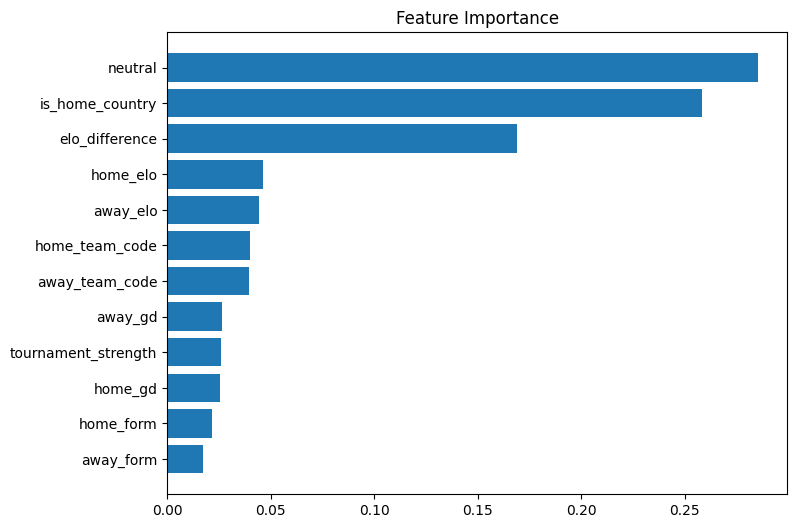

In [ ]:
import matplotlib.pyplot as plt

importance_df = importance_df.sort_values(
    by="Importance"
)

plt.figure(figsize=(8,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [ ]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": calibrated_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                Feature  Importance
2               neutral    0.217504
11       elo_difference    0.215208
4       is_home_country    0.195878
9              home_elo    0.059611
10             away_elo    0.057483
1        away_team_code    0.052733
0        home_team_code    0.046892
8               away_gd    0.041350
6             away_form    0.037025
7               home_gd    0.035121
5             home_form    0.022964
3   tournament_strength    0.018230
